# GAIA Level 2 — Plan-Reuse Analysis (lv2)

Compares the **baseline** (lv2 originals run *without* plan reuse) against the three
plan-reuse ranking strategies — **rank_by_step** (`total_tool_calls`),
**rank_by_token** (`total_tokens`), **rank_by_latency** (`total_latency_ms`) — all run
on the same lv2 test set (original GAIA tasks) with the lv2 paraphrase KB and
pre-computed embeddings.

Analyses: (1) completion rate, (2) accuracy (EM), (3) token savings, (4) latency
savings, (5) effectiveness vs retrieval similarity, (6) cross-strategy source agreement,
(7) savings conditioned on baseline cost, (8) findings summary.

In [1]:
%matplotlib inline
from pathlib import Path
import json, glob, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import pearsonr
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)

EKB = Path.cwd()
if not (EKB / "traces").exists() and (EKB.parent / "traces").exists(): EKB = EKB.parent
LVL = "lv2"
BASE_RUN  = f"gaia_lv2_x3"
STRATS = {"rank_by_step": f"gaia_lv2_plan_reuse_rank_by_step",
           "rank_by_token": f"gaia_lv2_plan_reuse_rank_by_token",
           "rank_by_latency": f"gaia_lv2_plan_reuse_rank_by_latency"}
TEST_JSONL = EKB / "data" / "gaia_paraphrased" / f"gaia_lv2_x3_test.jsonl"
test_ids = [json.loads(l)["task_id"] for l in open(TEST_JSONL) if l.strip()]
N = len(test_ids)
print("level:", LVL, "| test-set size N =", N)


level: lv2 | test-set size N = 84


In [2]:
def is_original(tid): return "__para" not in tid
def load_run(run, originals_only=False):
    rows = []
    for d in glob.glob(str(EKB / "traces" / "claude_native" / run / "*")):
        f = os.path.join(d, "normalized_trace.json")
        if not os.path.exists(f): continue
        t = json.load(open(f)); tid = t["query_id"]
        if originals_only and not is_original(tid): continue
        rows.append(dict(
            task_id=tid,
            steps=t.get("total_steps"), tokens=t.get("total_tokens"),
            latency_ms=t.get("total_latency_ms"),
            answered=bool(t.get("final_answer_pred") and str(t.get("final_answer_pred")).strip()),
            em=(t.get("exact_match") is True),
            cache_hit=bool(t.get("cache_hit")),
            src=t.get("cache_source_task_id"),
            sim=t.get("cache_source_similarity"),
        ))
    return pd.DataFrame(rows).drop_duplicates("task_id").set_index("task_id")

base = load_run(BASE_RUN, originals_only=True)
strat = {name: load_run(run) for name, run in STRATS.items()}
print("baseline:", len(base), "| " + " | ".join(f"{k}:{len(v)}" for k, v in strat.items()))


baseline: 82 | rank_by_step:82 | rank_by_token:82 | rank_by_latency:80


## 1. Task completion rate
Completion = produced a final answer. Rate is over the full test set `N` (a task with no
trace or a blank answer counts as not completed).

In [3]:
def completion_row(df, label):
    answered = int(df.answered.sum())
    return dict(set=label, n_traces=len(df), completed=answered, completion_rate=answered / N)
comp = pd.DataFrame([completion_row(base, "baseline")] +
                    [completion_row(strat[s], s) for s in STRATS])
display(comp.assign(completion_rate=lambda d: (d.completion_rate*100).round(1)))


,set,n_traces,completed,completion_rate
0,baseline,82,76,90.5
1,rank_by_step,82,75,89.3
2,rank_by_token,82,79,94.0
3,rank_by_latency,80,74,88.1


## 2. Task accuracy (exact-match rate)
`em_rate_of_N` treats missing/blank as wrong (true benchmark accuracy); `em_rate_of_completed`
conditions on tasks that produced an answer.

,set,em,em_rate_of_N,em_rate_of_completed
0,baseline,58,69.0,76.3
1,rank_by_step,60,71.4,80.0
2,rank_by_token,57,67.9,72.2
3,rank_by_latency,60,71.4,81.1


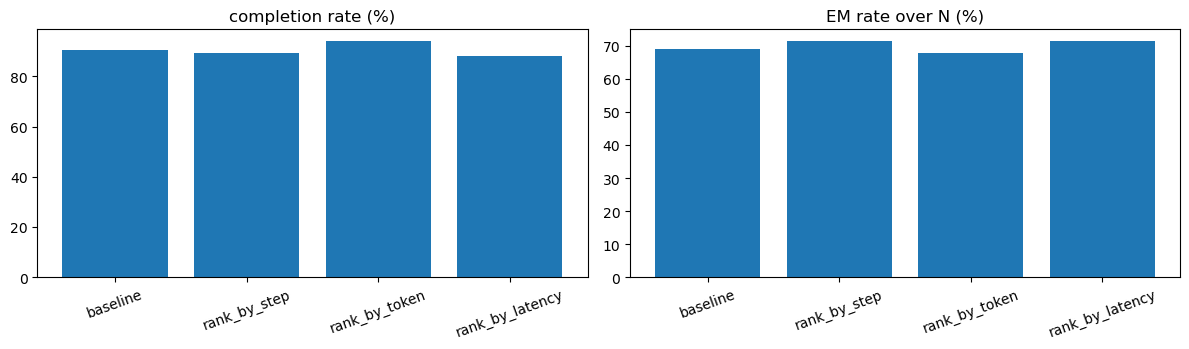

In [4]:
def acc_row(df, label):
    answered = int(df.answered.sum()); em = int(df.em.sum())
    return dict(set=label, em=em, em_rate_of_N=em / N,
                em_rate_of_completed=(em / answered if answered else np.nan))
acc = pd.DataFrame([acc_row(base, "baseline")] + [acc_row(strat[s], s) for s in STRATS])
display(acc.assign(em_rate_of_N=lambda d: (d.em_rate_of_N*100).round(1),
                   em_rate_of_completed=lambda d: (d.em_rate_of_completed*100).round(1)))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].bar(comp.set, comp.completion_rate*100); ax[0].set_title("completion rate (%)"); ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(acc.set, acc.em_rate_of_N*100);      ax[1].set_title("EM rate over N (%)");  ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


## 3. Token (cost) savings per ranking strategy
Matched per-task vs baseline (tasks present in both). `mean/median_saving` are per-task
fractions `(base-strat)/base`; `aggregate_saving` uses corpus totals. Positive ⇒ cheaper
than baseline.

In [5]:
def savings(sd, col):
    j = base[[col]].join(sd[[col]], lsuffix="_base", rsuffix="_strat", how="inner").dropna()
    j = j[j[col + "_base"] > 0]
    per = (j[col + "_base"] - j[col + "_strat"]) / j[col + "_base"]
    agg = (j[col + "_base"].sum() - j[col + "_strat"].sum()) / j[col + "_base"].sum()
    return dict(n_matched=len(j), mean_saving=per.mean(), median_saving=per.median(),
                aggregate_saving=agg,
                base_mean=j[col + "_base"].mean(), strat_mean=j[col + "_strat"].mean())
tok = pd.DataFrame([dict(strategy=s, **savings(strat[s], "tokens")) for s in STRATS])
display(tok.assign(mean_saving=lambda d:(d.mean_saving*100).round(1),
                   median_saving=lambda d:(d.median_saving*100).round(1),
                   aggregate_saving=lambda d:(d.aggregate_saving*100).round(1),
                   base_mean=lambda d:(d.base_mean/1000).round(0), strat_mean=lambda d:(d.strat_mean/1000).round(0))
        .rename(columns={"base_mean":"base_k","strat_mean":"strat_k"}))
print("(saving % positive = fewer tokens than baseline; base_k/strat_k in 1000s of tokens)")


,strategy,n_matched,mean_saving,median_saving,aggregate_saving,base_k,strat_k
0,rank_by_step,82,-24.0,2.8,-4.2,665.0,693.0
1,rank_by_token,82,-7.0,3.4,15.8,665.0,560.0
2,rank_by_latency,80,-14.0,-0.6,-5.2,607.0,638.0


(saving % positive = fewer tokens than baseline; base_k/strat_k in 1000s of tokens)


## 4. Latency savings per ranking strategy
Same matched comparison on wall-clock latency. Median is the headline (latency is
right-skewed even after outlier cleanup).

,strategy,n_matched,mean_saving,median_saving,aggregate_saving,base_s,strat_s
0,rank_by_step,82,-10.8,14.9,19.0,234.2,189.6
1,rank_by_token,82,-2.4,10.6,29.4,234.2,165.3
2,rank_by_latency,80,4.2,1.8,20.8,216.9,171.7


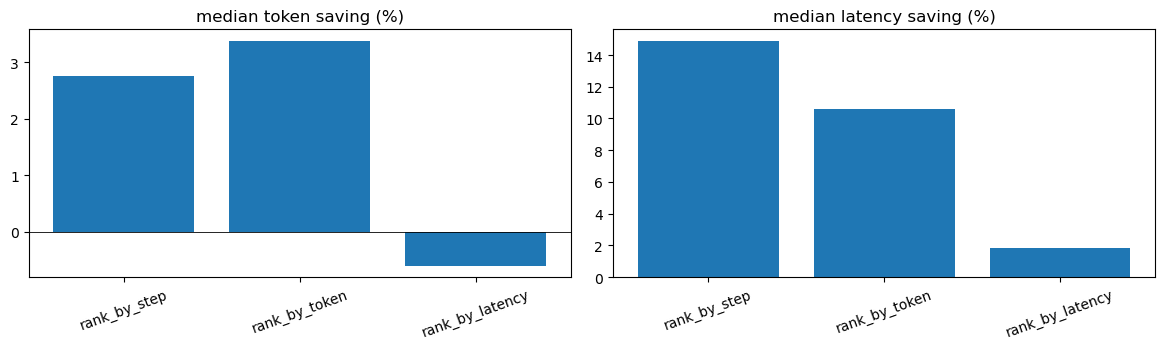

In [6]:
lat = pd.DataFrame([dict(strategy=s, **savings(strat[s], "latency_ms")) for s in STRATS])
display(lat.assign(mean_saving=lambda d:(d.mean_saving*100).round(1),
                   median_saving=lambda d:(d.median_saving*100).round(1),
                   aggregate_saving=lambda d:(d.aggregate_saving*100).round(1),
                   base_mean=lambda d:(d.base_mean/1000).round(1), strat_mean=lambda d:(d.strat_mean/1000).round(1))
        .rename(columns={"base_mean":"base_s","strat_mean":"strat_s"}))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
x = np.arange(len(STRATS)); names = list(STRATS)
ax[0].bar(x, [tok[tok.strategy==s].median_saving.iloc[0]*100 for s in names]); ax[0].set_xticks(x); ax[0].set_xticklabels(names, rotation=20); ax[0].set_title("median token saving (%)"); ax[0].axhline(0, color="k", lw=.6)
ax[1].bar(x, [lat[lat.strategy==s].median_saving.iloc[0]*100 for s in names]); ax[1].set_xticks(x); ax[1].set_xticklabels(names, rotation=20); ax[1].set_title("median latency saving (%)"); ax[1].axhline(0, color="k", lw=.6)
plt.tight_layout(); plt.show()


## 5. Effectiveness vs retrieval similarity
Core EKB hypothesis: does a more-similar retrieved KB trace (higher
`cache_source_similarity`) yield larger savings and higher accuracy? Pooled over all
cache-hit tasks of the three strategies.

244 cache-hit (strategy,task) rows | similarity range 0.802–0.987
  Pearson(sim, tok_saving) = -0.111 (p=0.0836)
  Pearson(sim, lat_saving) = -0.128 (p=0.045)
  Pearson(sim, EM)        = -0.086


,n,tok_saving,lat_saving,em_rate
sim_bin,,,,
0.80-0.85,15,-13.5,26.8,60.0
0.85-0.90,40,2.9,8.7,87.5
0.90-0.95,109,3.1,10.2,75.2
0.95-1.0,80,-48.8,-32.6,63.7


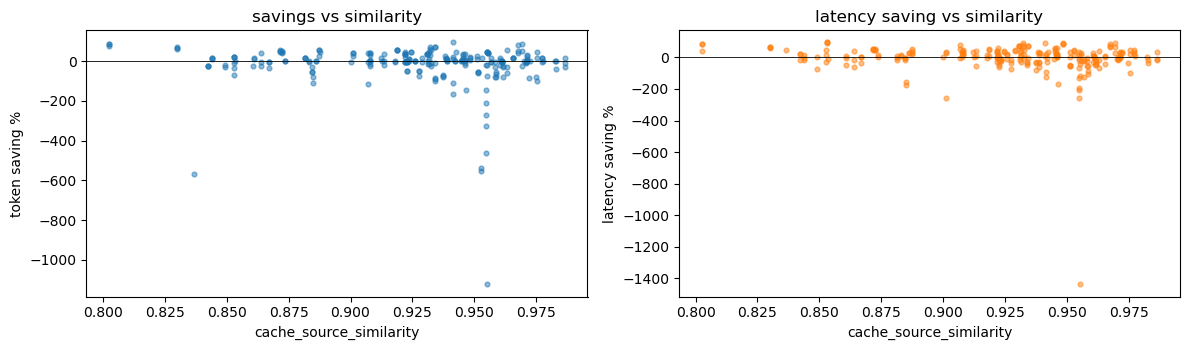

In [7]:
recs = []
for s, sd in strat.items():
    hit = sd[sd.cache_hit & sd.sim.notna()].copy()
    j = hit.join(base[["tokens", "latency_ms"]], rsuffix="_base", how="inner")
    j = j[(j.tokens_base > 0) & (j.latency_ms_base > 0)]
    j["tok_saving"] = (j.tokens_base - j.tokens) / j.tokens_base
    j["lat_saving"] = (j.latency_ms_base - j.latency_ms) / j.latency_ms_base
    j["strategy"] = s
    recs.append(j[["sim", "tok_saving", "lat_saving", "em", "strategy"]])
H = pd.concat(recs).reset_index(drop=True)
print(f"{len(H)} cache-hit (strategy,task) rows | similarity range "
      f"{H.sim.min():.3f}–{H.sim.max():.3f}")
for y in ["tok_saving", "lat_saving"]:
    r, p = pearsonr(H.sim, H[y]); print(f"  Pearson(sim, {y}) = {r:+.3f} (p={p:.3g})")
re_em, _ = pearsonr(H.sim, H.em.astype(float)); print(f"  Pearson(sim, EM)        = {re_em:+.3f}")

H["sim_bin"] = pd.cut(H.sim, [0, 0.8, 0.85, 0.9, 0.95, 1.01],
                      labels=["<0.80", "0.80-0.85", "0.85-0.90", "0.90-0.95", "0.95-1.0"])
binned = H.groupby("sim_bin", observed=True).agg(
    n=("sim", "size"), tok_saving=("tok_saving", "mean"),
    lat_saving=("lat_saving", "mean"), em_rate=("em", "mean"))
display(binned.assign(tok_saving=lambda d:(d.tok_saving*100).round(1),
                      lat_saving=lambda d:(d.lat_saving*100).round(1),
                      em_rate=lambda d:(d.em_rate*100).round(1)))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].scatter(H.sim, H.tok_saving*100, s=12, alpha=.5); ax[0].set_xlabel("cache_source_similarity"); ax[0].set_ylabel("token saving %"); ax[0].axhline(0,color="k",lw=.6); ax[0].set_title("savings vs similarity")
ax[1].scatter(H.sim, H.lat_saving*100, s=12, alpha=.5, color="tab:orange"); ax[1].set_xlabel("cache_source_similarity"); ax[1].set_ylabel("latency saving %"); ax[1].axhline(0,color="k",lw=.6); ax[1].set_title("latency saving vs similarity")
plt.tight_layout(); plt.show()


## 6. Cross-strategy source agreement
For each test task where all three strategies got a cache hit, do they retrieve the
**same** KB source task? When they diverge, does the source choice change the answer
(EM)?

In [8]:
S = pd.DataFrame({s: strat[s].src for s in STRATS})
EMs = pd.DataFrame({s: strat[s].em for s in STRATS})
both = S.dropna()                       # all 3 strategies hit
both_n = both.apply(lambda r: len(set(r)), axis=1)
print(f"tasks where all 3 strategies hit: {len(both)}")
print(f"  all-3 same source : {(both_n==1).sum()} ({(both_n==1).mean()*100:.0f}%)")
print(f"  2 share / 1 differs: {(both_n==2).sum()} ({(both_n==2).mean()*100:.0f}%)")
print(f"  all-3 different    : {(both_n==3).sum()} ({(both_n==3).mean()*100:.0f}%)")

div = both.index[both_n > 1]
emdiv = EMs.loc[EMs.index.isin(div)]
print(f"\namong {len(div)} divergent-source tasks:")
print(f"  EM differs across strategies on {(emdiv.nunique(axis=1) > 1).sum()} tasks "
      f"({(emdiv.nunique(axis=1) > 1).mean()*100:.0f}%)")
agree = both.index[both_n == 1]
print(f"\nEM rate when sources AGREE: {EMs.loc[EMs.index.isin(agree)].mean().mean()*100:.1f}%  | "
      f"when DIVERGE: {emdiv.mean().mean()*100:.1f}%")


tasks where all 3 strategies hit: 80
  all-3 same source : 63 (79%)
  2 share / 1 differs: 17 (21%)
  all-3 different    : 0 (0%)

among 17 divergent-source tasks:
  EM differs across strategies on 5 tasks (29%)

EM rate when sources AGREE: 75.1%  | when DIVERGE: 64.7%


## 7. Savings conditioned on baseline cost
Are savings proportional to how expensive the task is at baseline? If larger baseline
cost ⇒ larger absolute (and %) saving, EKB delivers the most value on hard tasks.

Pearson(baseline tokens, ABS token saving) = +0.320
Pearson(baseline tokens, %   token saving) = +0.104


,n,base_k,abs_saving_k,pct_saving
base_quartile,,,,
Q1 cheap,63,98.0,-11.0,-11.6
Q2,60,190.0,-46.0,-21.6
Q3,60,368.0,-210.0,-46.1
Q4 expensive,61,1934.0,325.0,18.6


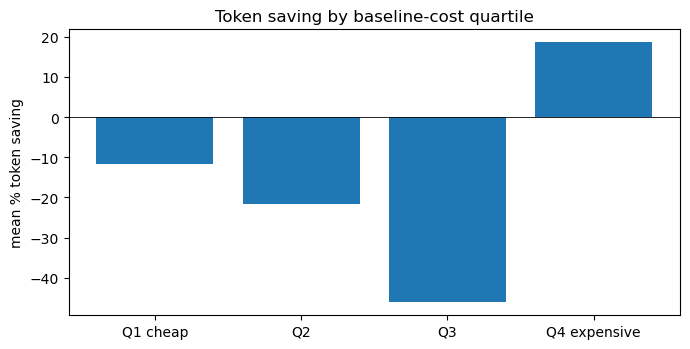

In [9]:
rows = []
for s in STRATS:
    j = base[["tokens", "latency_ms"]].join(strat[s][["tokens", "latency_ms"]],
                                            lsuffix="_base", rsuffix="_strat", how="inner").dropna()
    j = j[j.tokens_base > 0]
    j["abs_tok_saving"] = j.tokens_base - j.tokens_strat
    j["pct_tok_saving"] = j.abs_tok_saving / j.tokens_base
    j["strategy"] = s
    rows.append(j)
J = pd.concat(rows)
r1, _ = pearsonr(J.tokens_base, J.abs_tok_saving)
r2, _ = pearsonr(J.tokens_base, J.pct_tok_saving)
print(f"Pearson(baseline tokens, ABS token saving) = {r1:+.3f}")
print(f"Pearson(baseline tokens, %   token saving) = {r2:+.3f}")
J["base_quartile"] = pd.qcut(J.tokens_base, 4, labels=["Q1 cheap", "Q2", "Q3", "Q4 expensive"])
q = J.groupby("base_quartile", observed=True).agg(
    n=("tokens_base", "size"), base_k=("tokens_base", "mean"),
    abs_saving_k=("abs_tok_saving", "mean"), pct_saving=("pct_tok_saving", "mean"))
display(q.assign(base_k=lambda d:(d.base_k/1000).round(0),
                 abs_saving_k=lambda d:(d.abs_saving_k/1000).round(0),
                 pct_saving=lambda d:(d.pct_saving*100).round(1)))
plt.figure(figsize=(7, 3.6))
plt.bar(q.index.astype(str), (q.pct_saving*100)); plt.axhline(0, color="k", lw=.6)
plt.ylabel("mean % token saving"); plt.title("Token saving by baseline-cost quartile")
plt.tight_layout(); plt.show()


## 8. Findings summary

**What each analysis tells us**
1. **Completion rate** — does plan injection make the agent more/less likely to finish?
2. **Accuracy (EM)** — does forcing a retrieved plan help or hurt correctness vs baseline?
3. **Token savings** — does plan reuse reduce token cost, and which ranking signal saves most?
4. **Latency savings** — same for wall-clock (median is the trustworthy stat).
5. **Effectiveness vs retrieval similarity** — the core EKB test: a *positive* Pearson(sim, saving)
   and rising EM with similarity would confirm "more similar prior ⇒ more reusable."
6. **Cross-strategy source agreement** — if the three signals usually pick the *same* KB source,
   the ranking choice matters little; high divergence with EM differences means the source choice
   is consequential.
7. **Savings vs baseline cost** — a positive correlation means EKB pays off most on expensive/hard
   tasks (the ones worth optimizing).

A consolidated numeric summary is printed below; read it together with the per-section tables.

In [10]:
print(f"===== GAIA lv2 plan-reuse — consolidated summary (N={N}) =====\n")
print("Completion & accuracy:")
display(comp.merge(acc[["set", "em_rate_of_N"]], on="set")
        .assign(completion_rate=lambda d:(d.completion_rate*100).round(1),
                em_rate_of_N=lambda d:(d.em_rate_of_N*100).round(1)))
print("Median savings vs baseline (%):")
display(pd.DataFrame({"strategy": list(STRATS),
                      "token_saving_%": [round(tok[tok.strategy==s].median_saving.iloc[0]*100,1) for s in STRATS],
                      "latency_saving_%": [round(lat[lat.strategy==s].median_saving.iloc[0]*100,1) for s in STRATS]}))
print("Core EKB signal: Pearson(retrieval similarity, token saving) =",
      round(pearsonr(H.sim, H.tok_saving)[0], 3),
      "| Pearson(baseline tokens, abs saving) =", round(pearsonr(J.tokens_base, J.abs_tok_saving)[0], 3))


===== GAIA lv2 plan-reuse — consolidated summary (N=84) =====

Completion & accuracy:


,set,n_traces,completed,completion_rate,em_rate_of_N
0,baseline,82,76,90.5,69.0
1,rank_by_step,82,75,89.3,71.4
2,rank_by_token,82,79,94.0,67.9
3,rank_by_latency,80,74,88.1,71.4


Median savings vs baseline (%):


,strategy,token_saving_%,latency_saving_%
0,rank_by_step,2.8,14.9
1,rank_by_token,3.4,10.6
2,rank_by_latency,-0.6,1.8


Core EKB signal: Pearson(retrieval similarity, token saving) = -0.111 | Pearson(baseline tokens, abs saving) = 0.32
